# Fine tune membrane cut for nice display

In [1]:
import os
import skimage
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

In [2]:
def extract_center_face(im, IFcoords):

    shp = IFcoords.shape
    interface = np.zeros(shp)
    for x in range(shp[0]):
        for y in range(shp[1]):
            z = IFcoords[x,y]
            interface[x,y] = im[x,y,z-4:z+4].min()
            # interface[x,y] = im[x-fs:x+fs,y-fs:y+fs,z-fs:z+fs].mean()  #small mean filtering

    return interface

In [72]:
vmin = -0.0587
vmax = 0.3144*1.8

In [73]:
sample = 'G_3'

In [74]:
toppath = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/'

In [75]:
im0 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_preop_registered.tif'))[100:1100,50:550,:]
im1 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_postop_1_registered.tif'))[100:1100,50:550,:]
im2 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_postop_2_registered.tif'))[100:1100,50:550,:]

In [76]:
# im0 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_preop_rotcrop.tif'))[100:1100,50:550,:]
# im1 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_postop_1_rotcrop.tif'))[100:1100,50:550,:]
# im2 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_postop_2_rotcrop.tif'))[100:1100,50:550,:]

In [77]:
memcut0 = skimage.io.imread(os.path.join(toppath, 'membrane_cut', sample+'_preop__membrane_cut.tif'))
memcut1 = skimage.io.imread(os.path.join(toppath, 'membrane_cut', sample+'_postop_1__membrane_cut.tif'))
memcut2 = skimage.io.imread(os.path.join(toppath, 'membrane_cut', sample+'_postop_2__membrane_cut.tif'))

mempos0 = skimage.io.imread(os.path.join(toppath, 'membrane_cut_positions', sample+'_preop__membrane_cut_position.tif'))
mempos1 = skimage.io.imread(os.path.join(toppath, 'membrane_cut_positions', sample+'_postop_1__membrane_cut_position.tif'))
mempos2 = skimage.io.imread(os.path.join(toppath, 'membrane_cut_positions', sample+'_postop_2__membrane_cut_position.tif'))

In [80]:
sl = 700

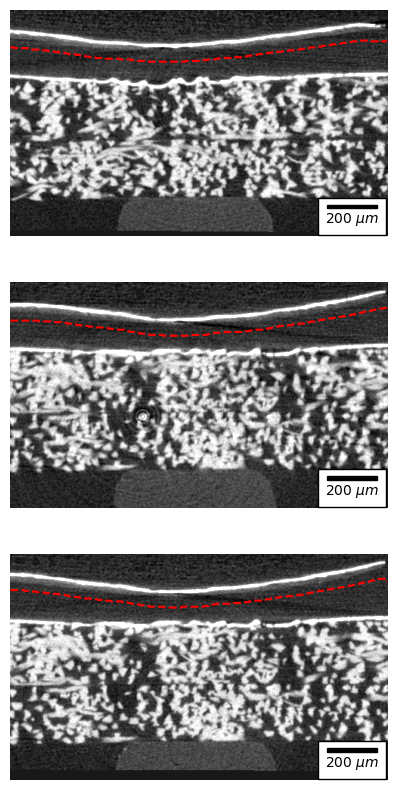

In [81]:
fig, axs = plt.subplots(3,1,figsize=(12,10))
axs[0].imshow(np.transpose(im0[sl,:,:], (1,0)), 'gray', vmin=vmin, vmax=vmax)
axs[1].imshow(np.transpose(im1[sl,:,:], (1,0)), 'gray', vmin=vmin, vmax=vmax)
axs[2].imshow(np.transpose(im2[sl,:,:], (1,0)), 'gray', vmin=vmin, vmax=vmax)

shift = 0
axs[0].plot(mempos0[sl,:], 'r--')
axs[1].plot(mempos1[sl,:], 'r--')
axs[2].plot(mempos2[sl,:], 'r--')

for ax in axs:
    ax.axis('off')
    scalebar = AnchoredSizeBar(ax.transData,
                       200/3, '200 $\mu m$', 'lower right', 
                       pad=0.5,
                       color='black',
                       frameon=True,
                       size_vertical=5)
    ax.add_artist(scalebar)
    # ax.set_title(sample+' slice: '+str(sl))

path = os.path.join(toppath, 'Paper_membrane_cross', sample+'_postop_2_cross_slide_'+str(sl)+'.png')
extent = axs[2].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig(path, bbox_inches=extent)

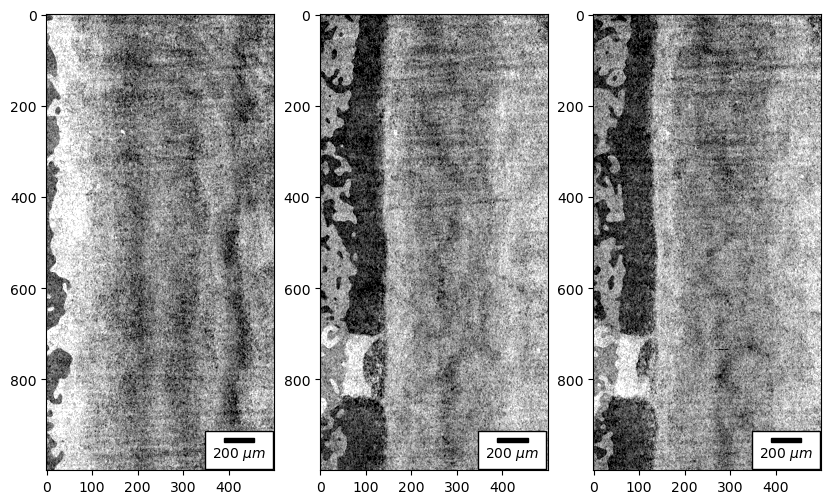

In [40]:
fig, axs = plt.subplots(1,3, figsize=(10,7))

vmin2 = 0.04
vmax2 = 0.15


axs[0].imshow(memcut0, 'gray', vmin=vmin2, vmax=vmax2)
axs[1].imshow(memcut1, 'gray', vmin=vmin2, vmax=vmax2)
axs[2].imshow(memcut2, 'gray', vmin=vmin2, vmax=vmax2)

for ax in axs:
    # ax.axis('off')
    scalebar = AnchoredSizeBar(ax.transData,
                       200/3, '200 $\mu m$', 'lower right', 
                       pad=0.5,
                       color='black',
                       frameon=True,
                       size_vertical=10)
    ax.add_artist(scalebar)